# 02 — Preprocesado y construcción de features

**Objetivo**: transformar las mediciones horarias en los **bloques del día** que alimentan la
tabla `ResumenDatosML` y construir las features de entrada del detector de anomalías.

```
CSV / endpoint (ancho) ──parsing──▶ horario largo ──features──▶ bloques del día ──▶ features modelo
```


## 0. Configuración

Cargamos librerías, definimos las rutas y fijamos las tres cosas que se repiten en todo el
proyecto: las **6 magnitudes objetivo** (con su color), y los **4 bloques del día** que dan
forma a la tabla `ResumenDatosML`.

| Bloque | Horas | Por qué existe |
|---|---|---|
| madrugada | 00–06 | actividad baja, nivel de fondo |
| mañana | 07–12 | hora punta → pico de NO₂ |
| tarde | 13–19 | sol + calor → pico de O₃ |
| noche | 20–23 | tráfico vespertino |

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Mismo estilo visual que el notebook 01
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "lines.linewidth": 2,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

# Rutas de entrada (histórico en formato ancho) y de salida (tabla procesada)
RUTA_HISTORICO = Path("../data/raw/datos_completos_2018_2026.csv")
RUTA_SALIDA    = Path("../data/processed/resumen_bloques.parquet")

# Las 6 magnitudes objetivo del proyecto: código de la API -> nombre
MAGNITUDES = {7: "NO", 8: "NO2", 9: "PM2.5", 10: "PM10", 12: "NOx", 14: "O3"}

# Color fijo por contaminante (Okabe-Ito, seguro para daltonismo)
PALETA = {
    "NO2": "#0072B2", "NO": "#56B4E9", "NOx": "#CC79A7",
    "O3": "#009E73", "PM10": "#E69F00", "PM2.5": "#D55E00",
}
ORDEN = ["NO2", "NO", "NOx", "O3", "PM10", "PM2.5"]

# Los 4 bloques del día: nombre -> (hora_inicio, hora_fin), ambas incluidas
BLOQUES = {
    "madrugada": (0, 6),
    "manana":    (7, 12),
    "tarde":     (13, 19),
    "noche":     (20, 23),
}
ORDEN_BLOQUES = ["madrugada", "manana", "tarde", "noche"]
print("Configuración lista.")

Configuración lista.


## 1. Del formato ancho al formato largo

El histórico viene en **formato ancho**: una fila por (estación, magnitud, día) con 24 columnas
de valor `H01..H24` y 24 flags `V01..V24`. Usamos `wide_a_largo`, el parser **compartido** del
proyecto (`src/etl/limpiar_datos.py`) — el mismo que usa la ingesta en tiempo real —, que
despivota esas 24 columnas a una fila por hora y descarta las horas con flag `N` (son
*placeholders*, no mediciones reales — lo vimos en el EDA).

In [2]:
# Reutilizamos el ÚNICO parser de despivotado del proyecto, definido en
# src/etl/limpiar_datos.py (el mismo que usa la ingesta en tiempo real).
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src", "etl")))
from limpiar_datos import wide_a_largo

MAGNITUDES_OBJETIVO = list(MAGNITUDES)  # [7, 8, 9, 10, 12, 14]

In [3]:
df = pd.read_csv(RUTA_HISTORICO, sep=";")
largo = wide_a_largo(df, MAGNITUDES_OBJETIVO)
largo["CONTAMINANTE"] = largo["MAGNITUD"].map(MAGNITUDES)

print(f"{len(largo):,} mediciones horarias válidas "
      f"({largo.FECHA.min()} → {largo.FECHA.max()})")
largo.head(3)

7,574,463 mediciones horarias válidas (2018-01-01 → 2026-04-30)


,ESTACION,MAGNITUD,FECHA,HORA,VALOR,VALIDO,CONTAMINANTE
0,4,7,2018-01-01,0,2.0,True,NO
1,4,7,2018-01-01,1,1.0,True,NO
2,4,7,2018-01-01,2,1.0,True,NO


## 2. Agregación por bloques del día → `ResumenDatosML`

Ahora reducimos las 24 horas de cada día a **4 filas** (una por bloque). Cada bloque resume el
comportamiento del contaminante en esa franja con estadísticos sencillos: media, máximo, mínimo,
desviación típica y a qué hora se dio el máximo/mínimo.

Añadimos además la **cobertura** = nº de horas válidas ÷ horas del bloque. Es clave para las
anomalías *operativas*: si un sensor se cae media tarde, la cobertura baja y lo detectamos.

In [4]:
# 2.1 Asignar cada hora (0-23) a su bloque
limites = [-1, 6, 12, 19, 23]  # (-1,6]=madrugada, (6,12]=mañana, (12,19]=tarde, (19,23]=noche
largo["BLOQUE"] = pd.cut(largo["HORA"], bins=limites, labels=ORDEN_BLOQUES).astype(str)

# Comprobación rápida: qué horas caen en cada bloque
largo.groupby("BLOQUE", observed=True)["HORA"].agg(["min", "max", "count"]).reindex(ORDEN_BLOQUES)

,min,max,count
BLOQUE,,,
madrugada,0,6,2223476
manana,7,12,1873008
tarde,13,19,2207631
noche,20,23,1270348


In [5]:
# 2.2 Estadísticos por (estación, magnitud, fecha, bloque)
CLAVES = ["ESTACION", "MAGNITUD", "FECHA", "BLOQUE"]

resumen = (
    largo.groupby(CLAVES, observed=True)
    .agg(
        MEDIA=("VALOR", "mean"),
        MAXIMO=("VALOR", "max"),
        MINIMO=("VALOR", "min"),
        STD=("VALOR", "std"),
        N_HORAS=("VALOR", "size"),
    )
    .reset_index()
)

# Hora exacta del máximo y del mínimo (idxmax/idxmin siguen el mismo orden de grupos
# que el groupby anterior, así que el alineamiento posicional es correcto)
idx_max = largo.groupby(CLAVES, observed=True)["VALOR"].idxmax()
idx_min = largo.groupby(CLAVES, observed=True)["VALOR"].idxmin()
resumen["HORA_MAXIMO"] = largo.loc[idx_max, "HORA"].to_numpy()
resumen["HORA_MINIMO"] = largo.loc[idx_min, "HORA"].to_numpy()

# Metadatos del bloque + features derivadas
resumen["HORA_INICIO"] = resumen["BLOQUE"].map(lambda b: BLOQUES[b][0])
resumen["HORA_FIN"]    = resumen["BLOQUE"].map(lambda b: BLOQUES[b][1])
duracion = {b: fin - ini + 1 for b, (ini, fin) in BLOQUES.items()}
resumen["COBERTURA"] = (resumen["N_HORAS"] / resumen["BLOQUE"].map(duracion)).round(3)
resumen["RANGO"]     = resumen["MAXIMO"] - resumen["MINIMO"]

print(f"{len(resumen):,} filas de bloque "
      f"(≈ estaciones × magnitudes × días × 4 bloques)")
resumen.head(4)

1,274,644 filas de bloque (≈ estaciones × magnitudes × días × 4 bloques)


,ESTACION,MAGNITUD,FECHA,BLOQUE,MEDIA,MAXIMO,MINIMO,STD,N_HORAS,HORA_MAXIMO,HORA_MINIMO,HORA_INICIO,HORA_FIN,COBERTURA,RANGO
0,4,7,2018-01-01,madrugada,1.142857,2.0,1.0,0.377964,7,0,1,0,6,1.0,1.0
1,4,7,2018-01-01,manana,1.833333,4.0,1.0,1.169045,6,9,7,7,12,1.0,3.0
2,4,7,2018-01-01,noche,2.000000,3.0,1.0,0.816497,4,20,23,20,23,1.0,2.0
3,4,7,2018-01-01,tarde,1.714286,4.0,1.0,1.112697,7,19,13,13,19,1.0,3.0


## 3. Features de calendario

Del EDA sabemos que los niveles dependen mucho del **mes** (estacionalidad: O₃ en verano, NOx en
invierno) y del **día de la semana** (menos tráfico en fin de semana). Extraemos esas señales de
la fecha para que el modelo pueda condicionar por ellas.

In [6]:
resumen["FECHA"] = pd.to_datetime(resumen["FECHA"])
resumen["ANO"]           = resumen["FECHA"].dt.year
resumen["MES"]           = resumen["FECHA"].dt.month
resumen["DIA_SEMANA"]    = resumen["FECHA"].dt.dayofweek        # 0=lunes ... 6=domingo
resumen["ES_FIN_SEMANA"] = resumen["DIA_SEMANA"].isin([5, 6])
resumen["CONTAMINANTE"]  = resumen["MAGNITUD"].map(MAGNITUDES)

resumen[["FECHA", "MES", "DIA_SEMANA", "ES_FIN_SEMANA", "BLOQUE", "CONTAMINANTE"]].head(4)

,FECHA,MES,DIA_SEMANA,ES_FIN_SEMANA,BLOQUE,CONTAMINANTE
0,2018-01-01,1,0,False,madrugada,NO
1,2018-01-01,1,0,False,manana,NO
2,2018-01-01,1,0,False,noche,NO
3,2018-01-01,1,0,False,tarde,NO


## 4. Valor esperado y desviación (baseline histórico)

Este es el corazón del detector. Para cada bloque calculamos **cuál era el valor esperable** según
la historia, condicionado exactamente a la jerarquía que recomendaba el EDA:
**(estación, magnitud, bloque, mes)**.

- `MEDIA_ESPERADA` = media histórica de ese grupo → es el *expected value* estadístico.
- `Z_SCORE` = cuántas desviaciones típicas se aleja el bloque de lo esperado.

El `Z_SCORE` es ya un **detector de anomalías baseline** por sí mismo (`|z| > 3` ≈ raro), y a la
vez una feature potente para el modelo principal (LSTM Autoencoder) del notebook 03.

> Nota: aquí la referencia se calcula sobre **todo** el histórico (tabla de consulta). En producción
> se ajustaría solo con el periodo de entrenamiento para no filtrar información del futuro.

In [7]:
CLAVES_BASE = ["ESTACION", "MAGNITUD", "BLOQUE", "MES"]

baseline = (
    resumen.groupby(CLAVES_BASE, observed=True)["MEDIA"]
    .agg(MEDIA_ESPERADA="mean", STD_ESPERADA="std")
    .reset_index()
)
resumen = resumen.merge(baseline, on=CLAVES_BASE, how="left")

resumen["DESVIACION"] = resumen["MEDIA"] - resumen["MEDIA_ESPERADA"]
resumen["Z_SCORE"]    = resumen["DESVIACION"] / resumen["STD_ESPERADA"].replace(0, np.nan)

print(f"Tabla de referencia (baseline): {len(baseline):,} combinaciones "
      "estación × magnitud × bloque × mes")
resumen[["CONTAMINANTE", "BLOQUE", "MES", "MEDIA", "MEDIA_ESPERADA", "Z_SCORE"]].head(4)

Tabla de referencia (baseline): 5,376 combinaciones estación × magnitud × bloque × mes


,CONTAMINANTE,BLOQUE,MES,MEDIA,MEDIA_ESPERADA,Z_SCORE
0,NO,madrugada,1,1.142857,21.179634,-0.817879
1,NO,manana,1,1.833333,60.567704,-0.876579
2,NO,noche,1,2.000000,52.578475,-0.738916
3,NO,tarde,1,1.714286,26.210693,-0.630885


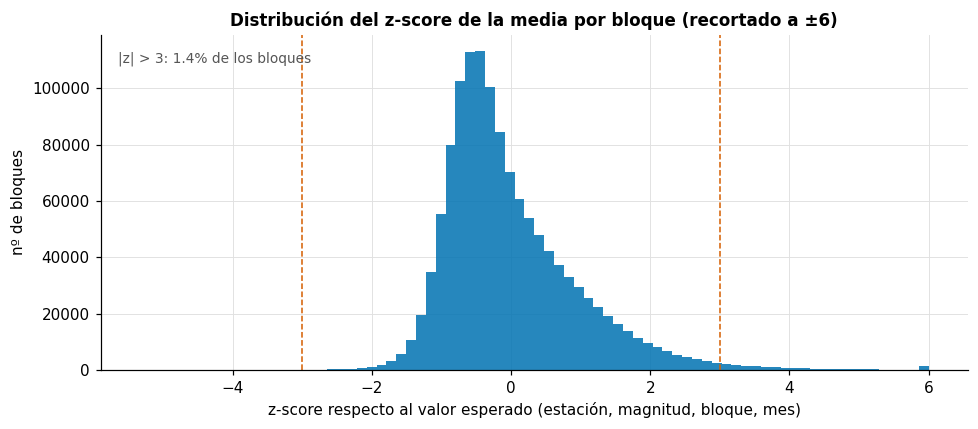

In [8]:
# ¿Tiene sentido el z-score? Debería centrarse en 0 con colas finas (los candidatos a anomalía)
fig, ax = plt.subplots(figsize=(9, 4))
z = resumen["Z_SCORE"].clip(-6, 6).dropna()
ax.hist(z, bins=80, color="#0072B2", alpha=0.85)
for umbral in (-3, 3):
    ax.axvline(umbral, color="#D55E00", linestyle="--", linewidth=1)
ax.set_title("Distribución del z-score de la media por bloque (recortado a ±6)")
ax.set_xlabel("z-score respecto al valor esperado (estación, magnitud, bloque, mes)")
ax.set_ylabel("nº de bloques")
pct = (z.abs() > 3).mean() * 100
ax.text(0.02, 0.95, f"|z| > 3: {pct:.1f}% de los bloques",
        transform=ax.transAxes, va="top", fontsize=9, color="#555")
plt.tight_layout(); plt.show()

## 5. Guardar la tabla procesada

Fijamos el orden de columnas (la estructura de `ResumenDatosML`) y guardamos en Parquet. Las tres
columnas del modelo — `ANOMALY_SCORE`, `IS_ANOMALY`, `EXPECTED_VALUE` — **no se calculan aquí**:
las añade el detector en el notebook 03. Aquí dejamos listo el `MEDIA_ESPERADA` estadístico, que
es su equivalente baseline.

In [9]:
RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)

COLUMNAS = [
    # identificación
    "ESTACION", "MAGNITUD", "CONTAMINANTE", "FECHA", "BLOQUE", "HORA_INICIO", "HORA_FIN",
    # calendario
    "ANO", "MES", "DIA_SEMANA", "ES_FIN_SEMANA",
    # estadísticos del bloque
    "N_HORAS", "COBERTURA", "MEDIA", "MAXIMO", "HORA_MAXIMO",
    "MINIMO", "HORA_MINIMO", "STD", "RANGO",
    # baseline histórico
    "MEDIA_ESPERADA", "STD_ESPERADA", "DESVIACION", "Z_SCORE",
]
resumen = (resumen[COLUMNAS]
           .sort_values(["ESTACION", "MAGNITUD", "FECHA", "HORA_INICIO"])
           .reset_index(drop=True))

resumen.to_parquet(RUTA_SALIDA, index=False)
print(f"Guardado en {RUTA_SALIDA}")
print(f"{len(resumen):,} filas × {resumen.shape[1]} columnas")
resumen.head()

Guardado en ..\data\processed\resumen_bloques.parquet
1,274,644 filas × 24 columnas


,ESTACION,MAGNITUD,CONTAMINANTE,FECHA,BLOQUE,HORA_INICIO,HORA_FIN,ANO,MES,DIA_SEMANA,...,MAXIMO,HORA_MAXIMO,MINIMO,HORA_MINIMO,STD,RANGO,MEDIA_ESPERADA,STD_ESPERADA,DESVIACION,Z_SCORE
0,4,7,NO,2018-01-01,madrugada,0,6,2018,1,0,...,2.0,0,1.0,1,0.377964,1.0,21.179634,24.498469,-20.036777,-0.817879
1,4,7,NO,2018-01-01,manana,7,12,2018,1,0,...,4.0,9,1.0,7,1.169045,3.0,60.567704,67.004076,-58.734370,-0.876579
2,4,7,NO,2018-01-01,tarde,13,19,2018,1,0,...,4.0,19,1.0,13,1.112697,3.0,26.210693,38.828636,-24.496407,-0.630885
3,4,7,NO,2018-01-01,noche,20,23,2018,1,0,...,3.0,20,1.0,23,0.816497,2.0,52.578475,68.449561,-50.578475,-0.738916
4,4,7,NO,2018-01-02,madrugada,0,6,2018,1,1,...,1.0,0,1.0,0,0.000000,0.0,21.179634,24.498469,-20.179634,-0.823710


## Conclusiones

1. **De horas a bloques**: cada día pasa de 24 mediciones horarias a **4 filas** (madrugada,
   mañana, tarde, noche) con estadísticos que capturan el régimen de cada franja sin diluir los
   picos, tal como validaron los perfiles diarios del EDA.
2. **Features del detector**: cada fila lleva calendario (mes, día de semana, fin de semana),
   forma del bloque (media, máx/mín y su hora, std, rango) y **cobertura** para las anomalías
   operativas de sensor.
3. **Valor esperado**: el baseline por (estación, magnitud, bloque, mes) da un `Z_SCORE` que ya
   funciona como detector estadístico y como feature para el modelo principal.
4. **Salida**: `data/processed/resumen_bloques.parquet`, la base de la tabla `ResumenDatosML`. El
   notebook 03 entrenará el LSTM Autoencoder sobre estas features y rellenará `ANOMALY_SCORE`,
   `IS_ANOMALY` y `EXPECTED_VALUE`.